
## FINANCIAL DATA
MODULE 4 | LESSON 1


---


# **OPTION PAYOFFS AND STRATEGIES**

|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** | Calls, Puts, Strikes, Volatility, Option payoffs  |
|**Keywords** |Break-even levels, Straddle, Strangle, Iron condor   |


---


*In the previous module, we examined stocks and cryptocurrencies.  In this module, we will examine the use of Python to compute and visualize option payoffs and prices, from single options to multi-option strategies.*

In [1]:
import math

import numpy as np
import QuantLib as ql

## 1. Options
In this Module, we will use an open-source Python package called `QuantLib`.  This is an industry-grade library written entirely in C++. Due to its performance efficiency and utility, it is widely used in academia and research. We will not dive deep into the internals of it, but we will use its option pricing capabilities in order to obtain the price for the European and American vanilla options in order to plot the P&L (Profit and Loss) of various strategies and introduce the sensitivity of the option's price to the Greeks.

As you recall from Module 4 of Financial Markets, there are two fields that describe the type of option:
1. The type of option: call or put.
2. The style of exercise: European or American.

There are also six numerical values that allow us to value the option:
1. Stock Price: S0
2. Strike Level: K
3. Time to expiration (here, this is given in calendar days): t
4. Volatility: sigma (which is annualized)
5. Risk-Free rate: r (which is annualized)
6. Dividend-Yield: dv (which will be omitted for simplicity)


In order to utilize the 'QuantLib' option pricing capabilities, several functions for pricing European and American options will be created. Additionally, a comparison will be presented between various methods of option pricing, such as the Black-Scholes model, Monte Carlo simulations, and Lattice methods (specifically, Binomial trees).

Bellow, you can see a simple function for pricing European Calls and Puts using 3 different pricing methods: Analytical, Binomial Tree and Monte Carlo.

In [2]:
def option_price_european(
    S0, K, days_to_maturity, r, sigma, call=True, engine="BS", steps=200, paths=10000
):
    """
    This function returns the price of a European Call with 3 different price engines: BS, BT and MC.
    """

    # Setting up the dates
    today = ql.Date().todaysDate()
    maturity = today + days_to_maturity

    # Choosing the type of the option
    if call:
        option_type = ql.Option.Call
    else:
        option_type = ql.Option.Put

    # Creating the payoff
    payoff = ql.PlainVanillaPayoff(option_type, K)

    europeanExercise = ql.EuropeanExercise(maturity)
    europeanOption = ql.VanillaOption(payoff, europeanExercise)

    # Setting up the option's characteristics
    spot = ql.SimpleQuote(S0)
    riskFreeTS = ql.YieldTermStructureHandle(
        ql.FlatForward(today, r, ql.Actual365Fixed())
    )
    volTS = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed())
    )

    # We will use the analytical way of pricing the options
    process = ql.BlackScholesProcess(ql.QuoteHandle(spot), riskFreeTS, volTS)

    if engine == "BS":
        engine = ql.AnalyticEuropeanEngine(process)
    elif engine == "BT":
        engine = ql.BinomialVanillaEngine(process, "crr", steps)
    elif engine == "MC":
        engine = ql.MCEuropeanEngine(
            process, "PseudoRandom", timeSteps=steps, requiredSamples=paths
        )
    europeanOption.setPricingEngine(engine)

    return europeanOption.NPV()  # NPV stands for Net Present Value

## 2. Getting the Option's Price

As you first learn options, be sure to distinguish the price from the payoff.  

The option's payoff is known precisely at expiration. Indeed, the payoff only applies at an option's expiration.
The option's price applies at every time from inception up until the payoff.
Clearly, pricing is a much more difficult undertaking than figuring out the payoff.

Let's learn to use pricing functions that are part of this Python module.
It is one thing to use a function to get an option's price.  
It's another to understand what that function does.
Keep in mind that there is an entire course, Derivative Pricing, that will provide the mathematics and intuition behind the pricing of these securities.
For now, let's just outline that there are two methods for pricing an option:
1. Analytic
2. Numeric

An analytic method uses mathematics, such as stochastic calculus, Fourier transforms, stochastic dominance, and other analytical methods, to develop a pricing equation.
A numeric method uses numerical or computational techniques, such as discretization (binomial trees, finite difference methods, finite element methods) or randomization (Monte Carlo sampling, agent-based models) to develop a numerical method through which the option price can be found.

Let's run one example of an analytical model called Black Scholes.
Let's run two examples of numerical models: binomial tree and Monte Carlo.

In the following code excerpt, we price our call three different ways:
1. Analytically with the Black Scholes model.
2. Numerically with a binomial tree.
3. Numerically with a Monte Carlo simulation.

In [3]:
callBS = round(
    option_price_european(
        100, 100, 30, 0.05, 0.2, call=True, engine="BS", steps=200, paths=10000
    ),
    4,
)
callBT = round(
    option_price_european(
        100, 100, 30, 0.05, 0.2, call=True, engine="BT", steps=200, paths=10000
    ),
    4,
)
callMC = round(
    option_price_european(
        100, 100, 30, 0.05, 0.2, call=True, engine="MC", steps=200, paths=10000
    ),
    4,
)
[callBS, callBT, callMC]

[2.4934, 2.4905, 2.4536]

As we can see, the prices are fairly close. This is to be expected. If we use the methods properly, the prices should not vary depending on which method we use.  Keep in mind that the numeric methods (e.g., Monte Carlo simulation) require a sufficiently high number of iterations so that they can converge to the proper solutions.
Now that we've priced the call option, let's price the put using these three methods.

In [4]:
putBS = round(
    option_price_european(
        100, 100, 30, 0.05, 0.2, call=False, engine="BS", steps=200, paths=10000
    ),
    4,
)
putBT = round(
    option_price_european(
        100, 100, 30, 0.05, 0.2, call=False, engine="BT", steps=200, paths=10000
    ),
    4,
)
putMC = round(
    option_price_european(
        100, 100, 30, 0.05, 0.2, call=False, engine="MC", steps=200, paths=10000
    ),
    4,
)
[putBS, putBT, putMC]

[2.0833, 2.0804, 2.0838]

Again, we have good agreement among the prices. Intentionally, we did not run a high number of iterations for the Monte Carlo method to illustrate how the results can be slightly off.

Whenever we compute option prices, we should get in the habit of checking our prices using put-call parity. Module 4 of Financial Markets showed us that:
$$\text{call} - \text{put} = S - Ke^{-(rt)}$$  
Let's check this for ourselves.  
Going forward, we'll use the option prices from the analytical form.
First, let's calculate the left-hand side of the put-call parity equation.

In [5]:
c = callBS
p = putBS
round(c - p, 6)

0.4101

In [6]:
S = 100
K = 100
r = 0.05
t = 30 / 365
round(S - K * math.exp(-r * t), 6)

0.410116

The difference is small, likely due to rounding and not an actual arbitrage.  Ensuring put-call parity holds means that our calculations have a consistency. Whenever you are asked to compute option prices, always check put-call parity. It avoids your making a careless mistake.
For any questions you see on CRTs or GWPs, be sure to apply put-call parity.
As you can see, it is computationally very easy.
Conceptually, it is quite intriguing.
It says that at any given time, a relationship among three different markets exists.
The 3 markets are:
1. options market: calls and puts
2. stock market: underlying stock
3. bond market: a risk-free bond whose term is the option's expiration

Now that we've seen some option payoffs and prices, let's continue our applied treatment of options by examining some of the strategies.

## 3. Option Strategies

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the seaborn style "Whitegrid"
sns.set_style("whitegrid")

In this section, we will illustrate the payoff and profit and loss (P&L) associated with an option. By specifying the option's characteristics, including its type (American or European) and position (long or short), we can effectively visualize the P&L across a range of underlying stock price levels.

To facilitate this visualization, we will employ the `Matplotlib` library, augmenting its aesthetic appeal with the `seaborn` style.


In [8]:
# Setting parameters

S0 = 100
K = 100
stock_prices = np.linspace(80, 120, 500)

call_payoff = np.maximum(stock_prices - K, 0)
put_payoff = np.maximum(K - stock_prices, 0)

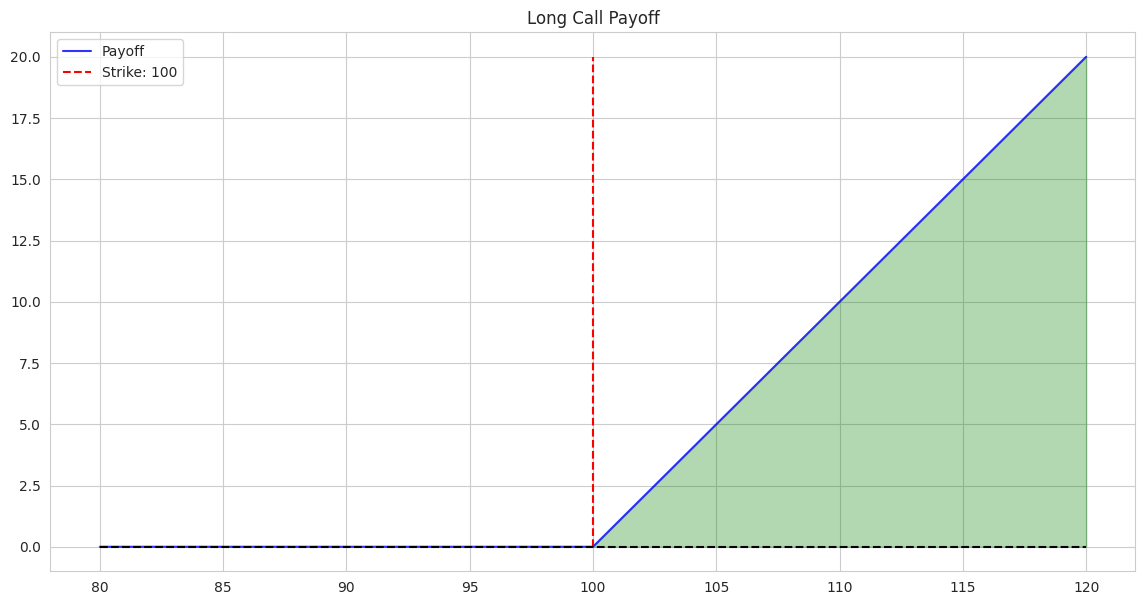

In [9]:
# Plotting the payoff of a long call option

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)

ax.fill_between(
    stock_prices, call_payoff, where=(call_payoff < 0), color="red", alpha=0.3
)
ax.fill_between(
    stock_prices, call_payoff, where=(call_payoff > 0), color="green", alpha=0.3
)
ax.plot(stock_prices, call_payoff, color="blue", alpha=0.8, label="Payoff")
ax.vlines(x=K, ymin=0, ymax=20, linestyle="--", color="red", label=f"Strike: {K}")
ax.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax.set_title("Long Call Payoff")
ax.legend()
plt.show()

Remember, that the option's payoff you see in books tends to neglect the premium you paid. Once you buy an option, you can not lose any additional money. However, long option positions can lose money if the options expires OTM.
Since we bought the call, we paid the $2.49 premium. Let's redraw the payoff taking the premium into account.


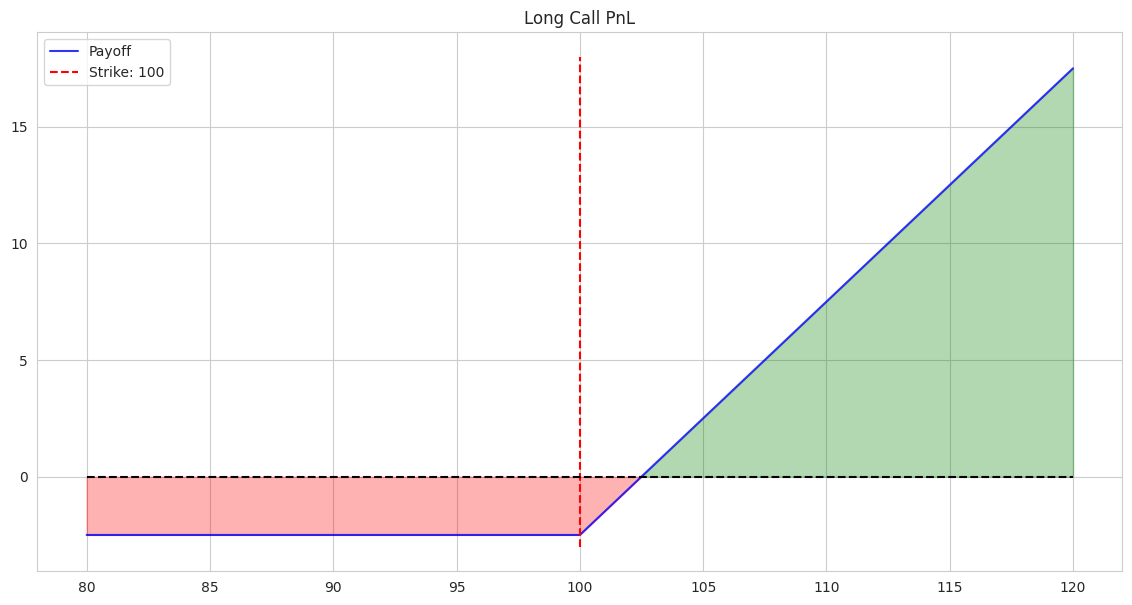

In [10]:
# Plotting the Long Call option's P&L

call_pnl = call_payoff - callBS

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.fill_between(stock_prices, call_pnl, where=(call_pnl < 0), color="red", alpha=0.3)
ax.fill_between(stock_prices, call_pnl, where=(call_pnl > 0), color="green", alpha=0.3)
ax.plot(stock_prices, call_pnl, color="blue", alpha=0.8, label="Payoff")
ax.vlines(x=K, ymin=-3, ymax=18, linestyle="--", color="red", label=f"Strike: {K}")
ax.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax.set_title("Long Call PnL")
ax.legend()
plt.show()

Clearly, the option is unprofitable not only if the stock price is below the strike level but also if the stock price is less than the sum of the strike and premium. So even if the option ends up ITM, we have to cover the cost of the premium to have a positive P&L.  

In fact, we can compute a break-even stock level for a call option.
The **break-even stock level** is the price at which the option holder has a net payoff of 0.
Call Break-Even Stock Level = Strike + Option Premium
In our example, this is
Call Break-Even Stock Level  = 100 + 2.49
                             = \$102.49
The break-even is where the stock payoff crosses the x-axis.

Let's see the seller's payoff.

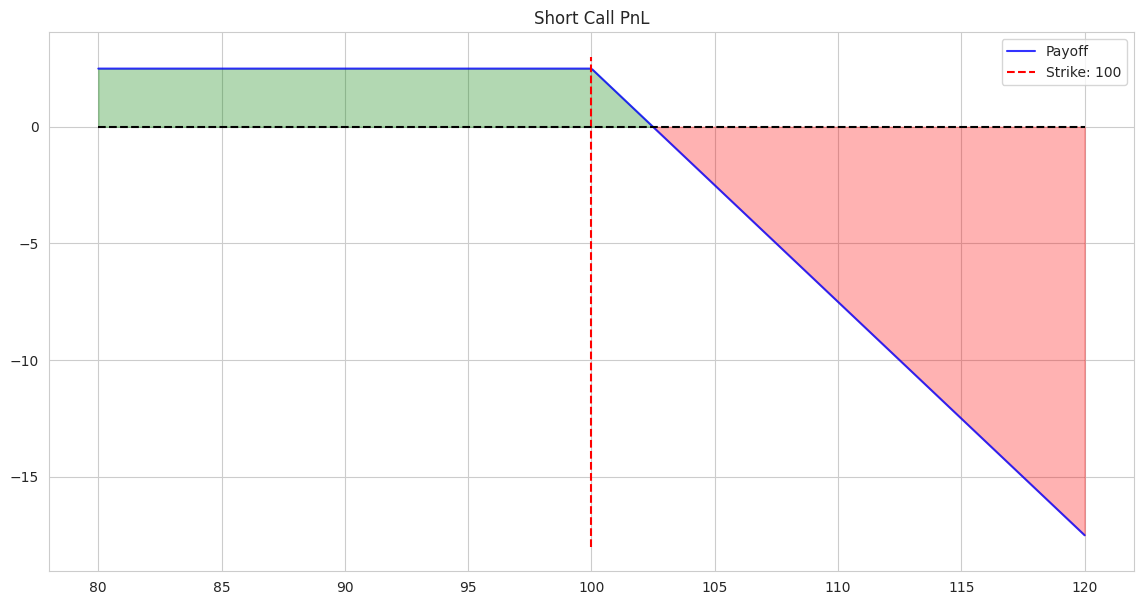

In [11]:
# Plotting the Short Call option's P&L

call_pnl_short = -call_pnl

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.fill_between(
    stock_prices, call_pnl_short, where=(call_pnl_short < 0), color="red", alpha=0.3
)
ax.fill_between(
    stock_prices, call_pnl_short, where=(call_pnl_short > 0), color="green", alpha=0.3
)
ax.plot(stock_prices, call_pnl_short, color="blue", alpha=0.8, label="Payoff")
ax.vlines(x=K, ymin=-18, ymax=3, linestyle="--", color="red", label=f"Strike: {K}")
ax.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax.set_title("Short Call PnL")
ax.legend()
plt.show()

Likewise, the seller's payoff for a call can be positive so long as the stock price exceeds the strike less the premium. To remind us that options are a zero-sum game, let's examine the two payoff diagrams together.


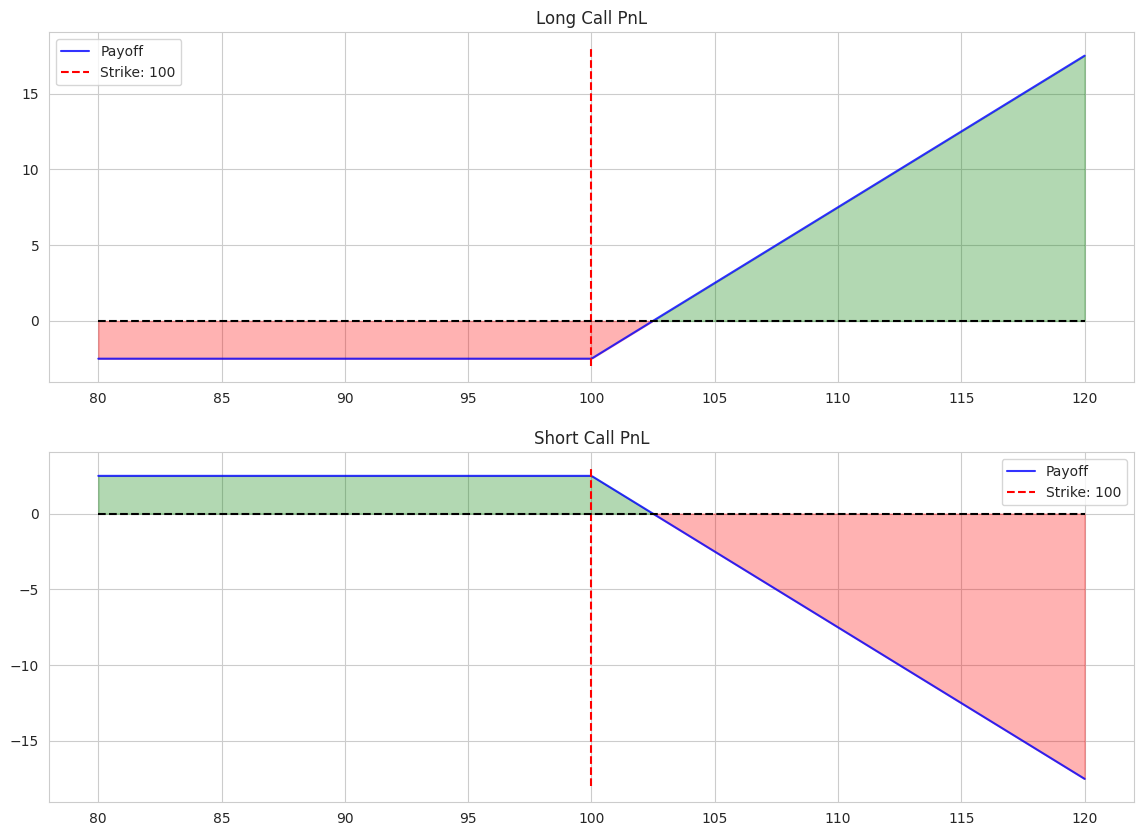

In [12]:
# Plotting both the Long and the Short call P&Ls together

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.set_size_inches(14, 10)

ax1.fill_between(stock_prices, call_pnl, where=(call_pnl < 0), color="red", alpha=0.3)
ax1.fill_between(stock_prices, call_pnl, where=(call_pnl > 0), color="green", alpha=0.3)
ax1.plot(stock_prices, call_pnl, color="blue", alpha=0.8, label="Payoff")
ax1.vlines(x=K, ymin=-3, ymax=18, linestyle="--", color="red", label=f"Strike: {K}")
ax1.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax1.set_title("Long Call PnL")
ax1.legend()

ax2.fill_between(
    stock_prices, call_pnl_short, where=(call_pnl_short < 0), color="red", alpha=0.3
)
ax2.fill_between(
    stock_prices, call_pnl_short, where=(call_pnl_short > 0), color="green", alpha=0.3
)
ax2.plot(stock_prices, call_pnl_short, color="blue", alpha=0.8, label="Payoff")
ax2.vlines(x=K, ymin=-18, ymax=3, linestyle="--", color="red", label=f"Strike: {K}")
ax2.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax2.set_title("Short Call PnL")
ax2.legend()

plt.show()

## 4. Zero Sum Games

Options are a zero sum game.  The buyer of the call has a payoff that is the mirror image of the seller's payoff.
Everywhere the long position is profitable (green), the seller is unprofitable (red).  
Everywhere the long position is unprofitable (red), the seller is profitable (green).

Notice the non-linearity in each graph. The strike is where the change in slope occurs. To one side of the strike, the payoff is a flat line. To the other side of the strike, the payoff is 45 degrees from the x-axis.

 - For long positions, the slope is upwards.
 - For short positions, the slope is downwards.

Note that long calls have unlimited upside; therefore, short calls have unlimited downside.
As this graph reminds us, it is prudent to hedge all short calls.

For completion, let's compute the break-even for puts and then graph long and short puts.

Put Break Even Stock Level = Option Strike - Premium
                           = 100 - 2.08
                           = 97.92
The put break-even stock level is where the option payoff crosses the x-axis.

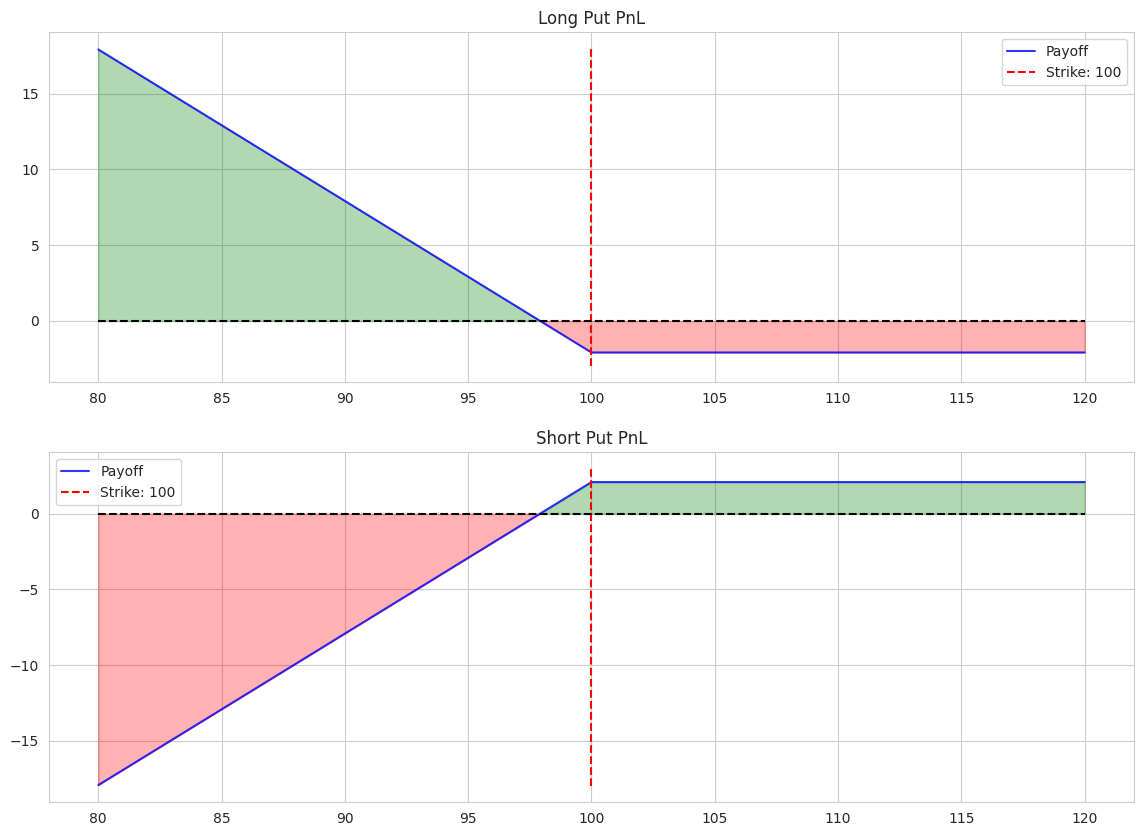

In [13]:
# Plotting both the Long and the Short put P&Ls together

put_pnl = put_payoff - putBS
put_pnl_short = -put_pnl

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.set_size_inches(14, 10)

ax1.fill_between(stock_prices, put_pnl, where=(put_pnl < 0), color="red", alpha=0.3)
ax1.fill_between(stock_prices, put_pnl, where=(put_pnl > 0), color="green", alpha=0.3)
ax1.plot(stock_prices, put_pnl, color="blue", alpha=0.8, label="Payoff")
ax1.vlines(x=K, ymin=-3, ymax=18, linestyle="--", color="red", label=f"Strike: {K}")
ax1.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax1.set_title("Long Put PnL")
ax1.legend()

ax2.fill_between(
    stock_prices, put_pnl_short, where=(put_pnl_short < 0), color="red", alpha=0.3
)
ax2.fill_between(
    stock_prices, put_pnl_short, where=(put_pnl_short > 0), color="green", alpha=0.3
)
ax2.plot(stock_prices, put_pnl_short, color="blue", alpha=0.8, label="Payoff")
ax2.vlines(x=K, ymin=-18, ymax=3, linestyle="--", color="red", label=f"Strike: {K}")
ax2.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax2.set_title("Short Put PnL")
ax2.legend()


plt.show()

We see the same story:
The long and short payoffs are mirror images of each other, reflecting the zero-sum game of options.
At any given stock price, one side has a profit (shown in green) and the other side has a loss (shown in red).
Each graph is non-linear.  
The slopes are still 45 degrees; however, for the long position, the slope is negative,
and for the short position, the slope is positive.
Note: Even if the option is ITM, the buyer still needs to cover the cost of the premium for the option to be profitable. Also, it is relatively easy to lose 100%.


## 5. Option Combinations

Another strategy involves trading volatility. Suppose we are unsure of the direction but believe that volatility will increase.
We can buy a call and a put at the same strike. This is an option straddle.

Remember, you don't have to get the direction of the underlying right.


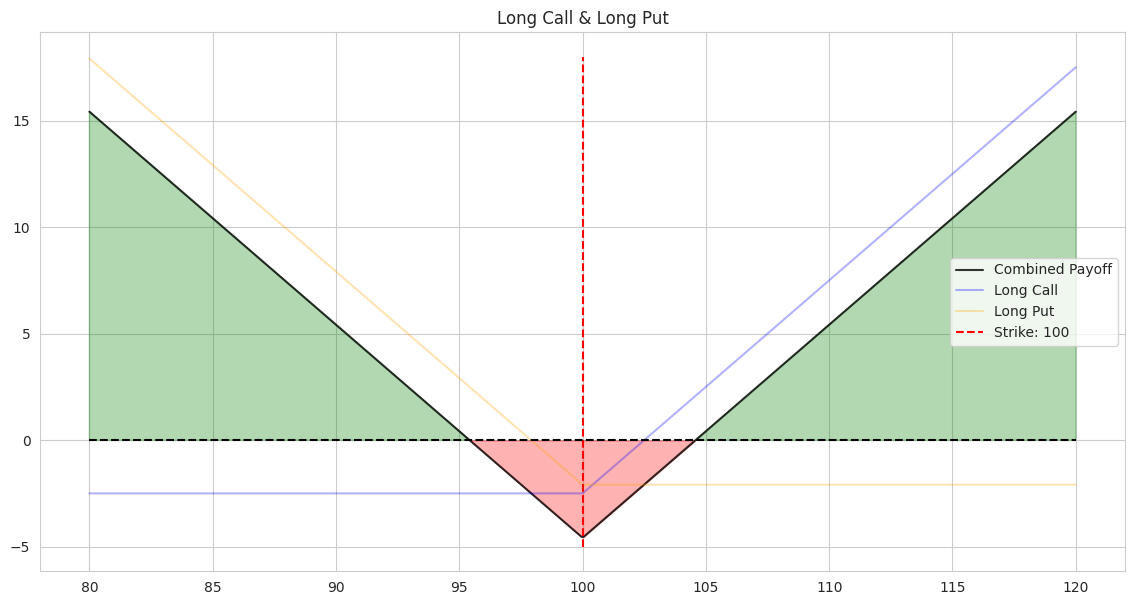

In [14]:
# Plotting a combined payoff of a Long call and a long put with the same strike

pnl_combined_long_CallPut = call_pnl + put_pnl

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.fill_between(
    stock_prices,
    pnl_combined_long_CallPut,
    where=(pnl_combined_long_CallPut < 0),
    color="red",
    alpha=0.3,
)
ax.fill_between(
    stock_prices,
    pnl_combined_long_CallPut,
    where=(pnl_combined_long_CallPut > 0),
    color="green",
    alpha=0.3,
)
ax.plot(
    stock_prices,
    pnl_combined_long_CallPut,
    color="black",
    alpha=0.8,
    label="Combined Payoff",
)
ax.plot(stock_prices, call_pnl, color="blue", alpha=0.3, label="Long Call")
ax.plot(stock_prices, put_pnl, color="orange", alpha=0.3, label="Long Put")
ax.vlines(x=K, ymin=-5, ymax=18, linestyle="--", color="red", label=f"Strike: {K}")
ax.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax.set_title("Long Call & Long Put")
ax.legend()


plt.show()

Notice the position is unprofitable unless the price moves about \$4.58 in either direction.
Option strategies that involve buying two options mean that the position has to cover the cost of two premiums.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

Let's look at some less expensive ways to execute volatility strategies.
Instead of only buying two options, let's also sell two options.
Suppose we believe the stock will only move \$10.
We can sell a put at a strike of 90. We can sell a call at a strike of 110.
Let's price each one.


In [15]:
callBS2 = round(
    option_price_european(
        100, 110, 30, 0.05, 0.2, call=True, engine="BS", steps=200, paths=10000
    ),
    4,
)
putBS2 = round(
    option_price_european(
        100, 90, 30, 0.05, 0.2, call=False, engine="BS", steps=200, paths=10000
    ),
    4,
)
print([callBS2, putBS2])

[0.1426, 0.0586]


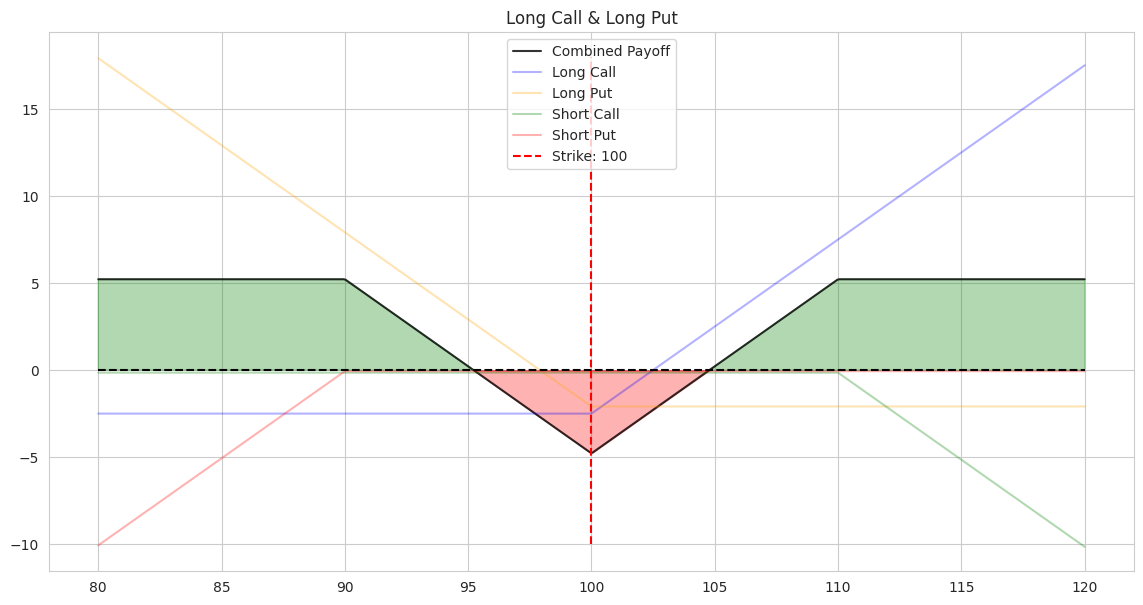

In [16]:
# Plotting a combined payoff of a Long call, a long put, a short call and a short put with varying strikes

call_pnl_2 = -np.maximum(stock_prices - 110, 0) - callBS2
put_pnl_2 = -np.maximum(90 - stock_prices, 0) - putBS2
pnl_combined_4_options = call_pnl + put_pnl + call_pnl_2 + put_pnl_2

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.fill_between(
    stock_prices,
    pnl_combined_4_options,
    where=(pnl_combined_4_options < 0),
    color="red",
    alpha=0.3,
)
ax.fill_between(
    stock_prices,
    pnl_combined_4_options,
    where=(pnl_combined_4_options > 0),
    color="green",
    alpha=0.3,
)
ax.plot(
    stock_prices,
    pnl_combined_4_options,
    color="black",
    alpha=0.8,
    label="Combined Payoff",
)
ax.plot(stock_prices, call_pnl, color="blue", alpha=0.3, label="Long Call")
ax.plot(stock_prices, put_pnl, color="orange", alpha=0.3, label="Long Put")
ax.plot(stock_prices, call_pnl_2, color="green", alpha=0.3, label="Short Call")
ax.plot(stock_prices, put_pnl_2, color="red", alpha=0.3, label="Short Put")
ax.vlines(x=K, ymin=-10, ymax=18, linestyle="--", color="red", label=f"Strike: {K}")
ax.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax.set_title("Long Call & Long Put")
ax.legend()


plt.show()

Now we construct an option strategy with four options.

## 6. Comparing Volatility Strategies

Plan A:  Buy a straddle.   Cost: \\$4.59.

Plan B:  Buy an iron butterfly. (4.59 - 0.20) =\\$4.39

The iron butterfly involves a long straddle (buying a call and put at the same strike) and also a short straddle (selling an OTM put at a low strike and selling an OTM call at a high strike).
The iron butterfly gives up a potential upside for a rebate of the option premium.
Individually, we have

1 short put at 90  </br>
1 long call at 100  </br>
1 long put at 100  </br>
1 short call at 110  </br>

The long iron butterfly trader is conservatively long volatility: even if volatility increases significantly, the long iron butterfly's P&L is capped at about \\$5.  That's because the long call's gain past \\$110 level is offset by the loss in the short call at strike \\$110.

The long straddle trader is aggressively long volatility: the more volatility, the more their P&L.
For example, if the final stock price is 115, then


long put(100)   =  0  </br>
long call(100)  = 15  </br>
Net Profit =     \\$15  </br>

Indeed, \\$15 is the maximum revenue. When the \\$4.59 cost is taken into consideration, the maximum P&L is
\\$15 - \\$4.59 = \\$10.41



## 7. Saving
Graphs are good for visualizing. Sometimes, the intended consumer of the graph is just the programmer/analyst, as they confirm their findings. Other times, some graphs are meant for the traders, portfolio managers, or risk managers.

Python makes it easy to save plots. Here's a simple function to save the plot as a .jpeg file.


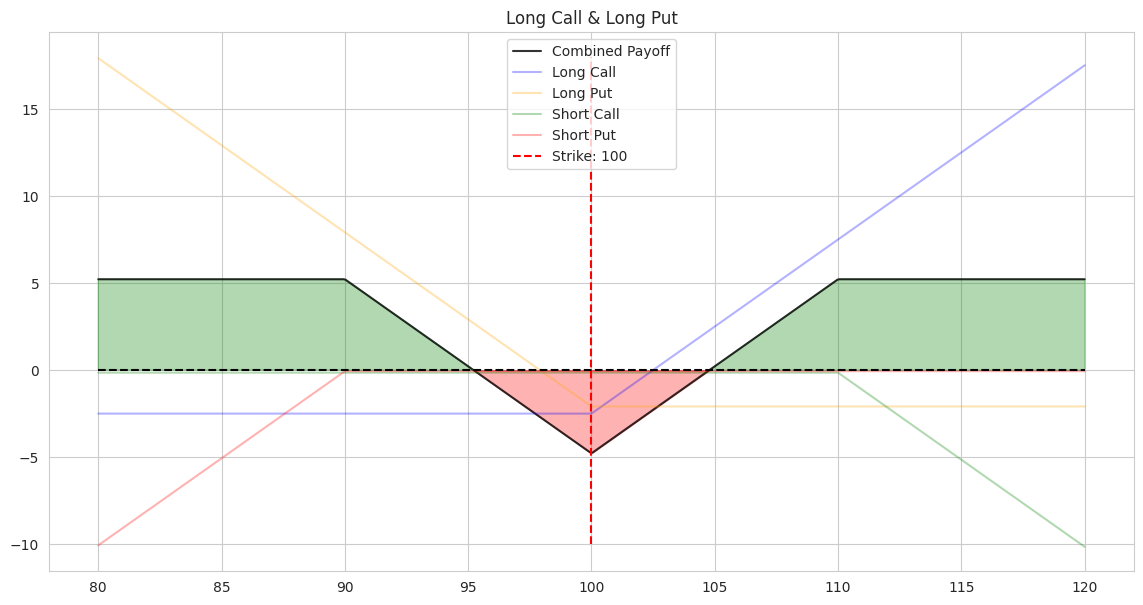

In [17]:
# Plotting a combined payoff of a Long call, a long put, a short call and a short put with varying strikes

call_pnl_2 = -np.maximum(stock_prices - 110, 0) - callBS2
put_pnl_2 = -np.maximum(90 - stock_prices, 0) - putBS2
pnl_combined_4_options = call_pnl + put_pnl + call_pnl_2 + put_pnl_2

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.fill_between(
    stock_prices,
    pnl_combined_4_options,
    where=(pnl_combined_4_options < 0),
    color="red",
    alpha=0.3,
)
ax.fill_between(
    stock_prices,
    pnl_combined_4_options,
    where=(pnl_combined_4_options > 0),
    color="green",
    alpha=0.3,
)
ax.plot(
    stock_prices,
    pnl_combined_4_options,
    color="black",
    alpha=0.8,
    label="Combined Payoff",
)
ax.plot(stock_prices, call_pnl, color="blue", alpha=0.3, label="Long Call")
ax.plot(stock_prices, put_pnl, color="orange", alpha=0.3, label="Long Put")
ax.plot(stock_prices, call_pnl_2, color="green", alpha=0.3, label="Short Call")
ax.plot(stock_prices, put_pnl_2, color="red", alpha=0.3, label="Short Put")
ax.vlines(x=K, ymin=-10, ymax=18, linestyle="--", color="red", label=f"Strike: {K}")
ax.hlines(y=0, xmin=80, xmax=120, linestyle="--", color="black")
ax.set_title("Long Call & Long Put")
ax.legend()
plt.savefig("myOptionStrategy.jpeg")

plt.show()

## 8. Conclusion

In this lesson, we examined the two methods of pricing options: analytical and numerical.  We examined option strategies that use single options and multiple options.  We related the level of bullishness or bearishness to the type of option strategy using combinations of calls and puts at different strikes.  In the next module, we examine the sensitivities of options to their underlying.

---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
